In [3]:
%run general_functions.ipynb

In [4]:
variables = { 
    'SST' : {'var_glodap':'temperature', 'var_name':'SST', 'var_nemo':'sosstsst', 'unit':r'$^\circ$C', 'v':10},
    'Surface alkalinity' : {'var_glodap':'TAlk', 'var_name':'ALK', 'var_nemo':'ALK', 'unit':r'μ mol $\mathregular{kg^{-1}}$', 'v':50},
    'Surface salinity' : {'var_glodap':'salinity', 'var_name':'SSS', 'var_nemo':'sosaline', 'unit':'psu', 'v':5},
}

In [3]:
def discretised_cmap(ds_in):
    
    vmin, vmax = float(np.nanmin(ds_in.values)), float(np.nanmax(ds_in.values))
    if vmin < 0 < vmax:
        vmax_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -vmax_abs, vmax_abs
        cmap, extend = cm.prinsenvlag_r, 'both'
    else:
        cmap, extend = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True), 'max'
    cmap, norm = create_discrete_cmap(cmap, 20)

    return cmap, extend

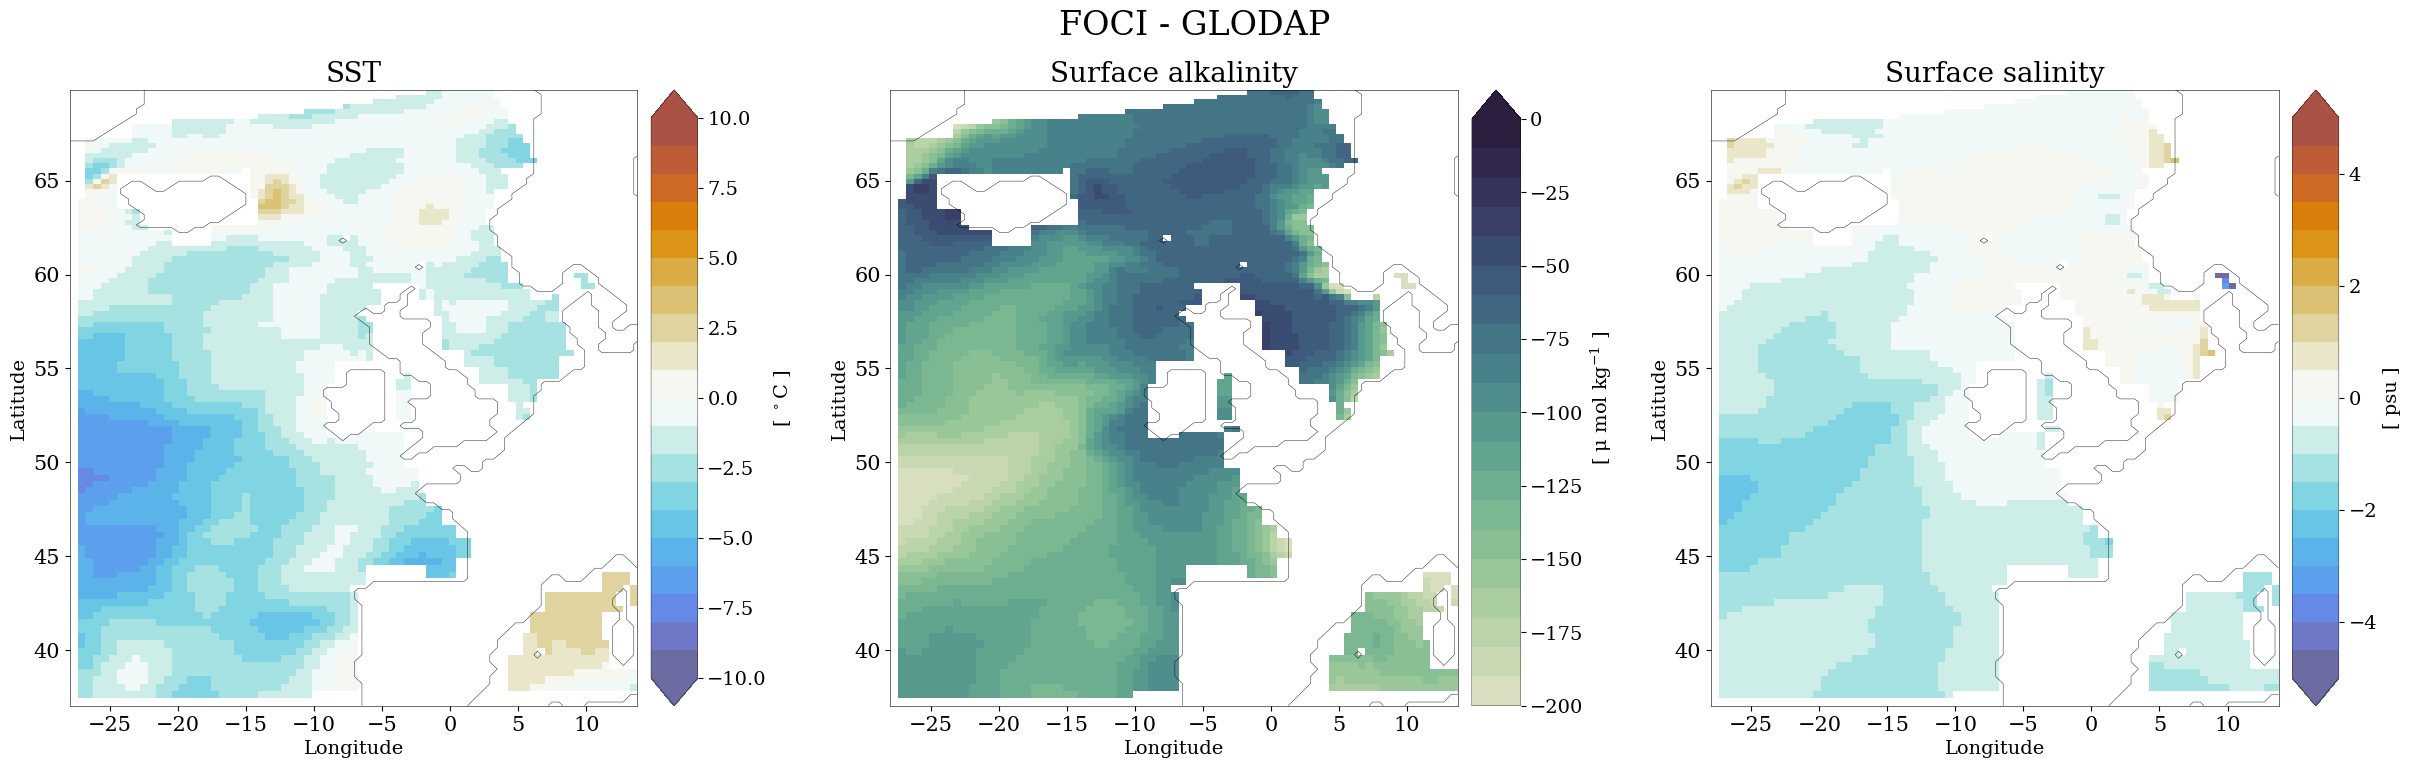

In [168]:
fig, axes = plt.subplots(1,3, figsize=(30, 8))

for ax, (name, keys) in zip(axes, variables.items()):
        
    var_glodap = keys['var_glodap']
    var_name = keys['var_name']
    var_nemo = keys['var_nemo']
    unit = keys['unit']
    mesh_mask_sliced = mesh_mask.sel(x=slice(519, 595), y=slice(329, 435))
    
    path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/' 
    GLODAP = xr.open_dataset(path+f'GLODAPv2.2016b_MappedClimatologies/GLODAPv2.2016b.{var_glodap}.nc')
    if var_name in ['ALK','DIC','PO4']:
        FOCI = xr.open_mfdataset(path+f'data_for_chiara/{var_name}_upper100m_cut/*.nc').isel(deptht=0)
    else: 
        FOCI = xr.open_mfdataset(path+f'data_for_chiara/{var_name}_cut/*.nc')        
    
    GLODAP = GLODAP.assign_coords(
        lon=((GLODAP.lon + 180) % 360) - 180
    ).sortby("lon")
    
    GLODAP[var_glodap] = GLODAP[var_glodap].isel(depth_surface=0).sel(lon=slice(-27.5,11), lat=slice(37,70))
    FOCI[var_nemo] = FOCI[var_nemo].mean('time_counter')
    
    # --- Define target grid (NEMO T-grid) ---
    target_grid = xr.Dataset(
        {
            "lat": (["y", "x"], FOCI["nav_lat"].values),
            "lon": (["y", "x"], FOCI["nav_lon"].values),
        }
    )

    # --- Build regridder ---
    regridder = xe.Regridder(
        GLODAP,
        target_grid,
        method="bilinear",
        periodic=True,
    )

    # --- Horizontal interpolation ---
    var_on_nemo = regridder(GLODAP[var_glodap])    
    diff = FOCI[var_nemo] - var_on_nemo
    diff = diff.where(FOCI[var_nemo])
    
    cmap, extend = discretised_cmap(diff)    
    cmap, norm = create_discrete_cmap(cmap, 20)  
    
    lat, lon = FOCI['nav_lon'].mean('y'), FOCI['nav_lat'].mean('x')
    
    v = keys['v']
    if var_name == 'ALK':
        vmin, vmax = -v-150, 0
    else:
        vmin, vmax = -v,v
    im = ax.pcolormesh(lat, lon, diff, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.contour(lat, lon, mesh_mask_sliced['tmask'], levels=[0.5], colors='black', linewidths=.3)

    fineline(ax,0.4)
    c_map = fig.colorbar(im, ax=ax, 
        aspect=12,
        pad=0.02,location='right', extend=extend)
    
    c_map.set_label(f'[ {unit} ]', fontsize=14)
    c_map.outline.set_linewidth(0.25)
    c_map.ax.tick_params(labelsize=14)
    
    ax.set_xlabel('Longitude', fontsize=14)
    ax.set_ylabel('Latitude', fontsize=14)
    ax.set_title(f'{name}')
    
fig.suptitle('FOCI - GLODAP', fontsize=24)

pass

In [16]:
path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/GLODAPv2.2016b_MappedClimatologies/'

gl_alkalinity = xr.open_dataset(path+'GLODAPv2.2016b.TAlk.nc')['TAlk']
gl_dic = xr.open_dataset(path+'GLODAPv2.2016b.PI_TCO2.nc')['PI_TCO2']
gl_temperature = xr.open_dataset(path+'GLODAPv2.2016b.temperature.nc')['temperature']
gl_salinity = xr.open_dataset(path+'GLODAPv2.2016b.salinity.nc')['salinity']

shape = gl_alkalinity.shape

mask = (
    np.isfinite(gl_alkalinity) &
    np.isfinite(gl_dic) &
    np.isfinite(gl_temperature) &
    np.isfinite(gl_salinity)
)

mask_flat = mask.values.ravel()

TA = gl_alkalinity.values.ravel()[mask_flat]
DIC = gl_dic.values.ravel()[mask_flat]
T = gl_temperature.values.ravel()[mask_flat]
S = gl_salinity.values.ravel()[mask_flat]

valid = np.isfinite(TA) & np.isfinite(DIC) & np.isfinite(T) & np.isfinite(S)

TA = TA[valid]
DIC = DIC[valid]
T = T[valid]
S = S[valid]

kwargs = dict(
    par1=TA,
    par2=DIC,
    par1_type=1,
    par2_type=2,
    temperature=T,
    salinity=S
)

res = pyco2.sys(**kwargs)

In [35]:
res_arrays = {}

for k, v in res.items():
    arr = np.full(gl_alkalinity.size, np.nan)
    arr[mask_flat] = v
    res_arrays[k] = xr.DataArray(
        arr.reshape(gl_alkalinity.shape),
        dims=gl_alkalinity.dims,
        coords=gl_alkalinity.coords
    )

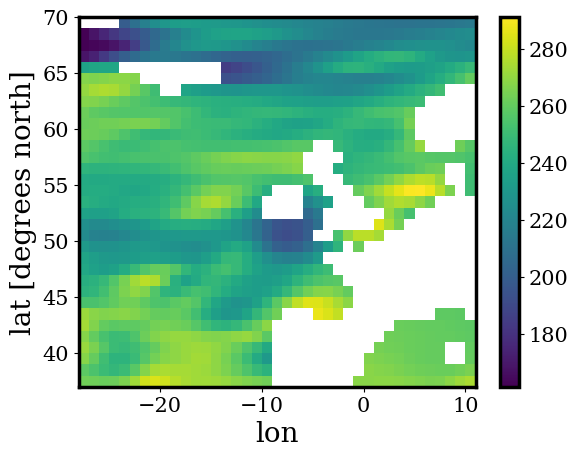

In [55]:
res_arrays['pCO2'] = res_arrays['pCO2'].assign_coords(
    lon=((res_arrays['pCO2'].lon + 180) % 360) - 180
).sortby("lon")

res_arrays['pCO2'].isel(depth_surface=0).sel(lon=slice(-27.5,11), lat=slice(37,70)).plot()